In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        '''print(os.path.join(dirname, filename))'''

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import warnings 
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM,GRU,  Dense, Dropout 

In [4]:
df=pd.read_csv(r'/kaggle/input/datasets/sumanthvrao/daily-climate-time-series-data/DailyDelhiClimateTrain.csv')

In [5]:
df.shape

(1462, 5)

In [6]:
df.columns

Index(['date', 'meantemp', 'humidity', 'wind_speed', 'meanpressure'], dtype='object')

In [7]:
df.dtypes

date             object
meantemp        float64
humidity        float64
wind_speed      float64
meanpressure    float64
dtype: object

Convert date to datetime object

In [8]:
df['date']=pd.to_datetime(df['date'])

#set date as index
df=df.set_index('date')

EDA to understand about the data

Text(0, 0.5, 'Temperature')

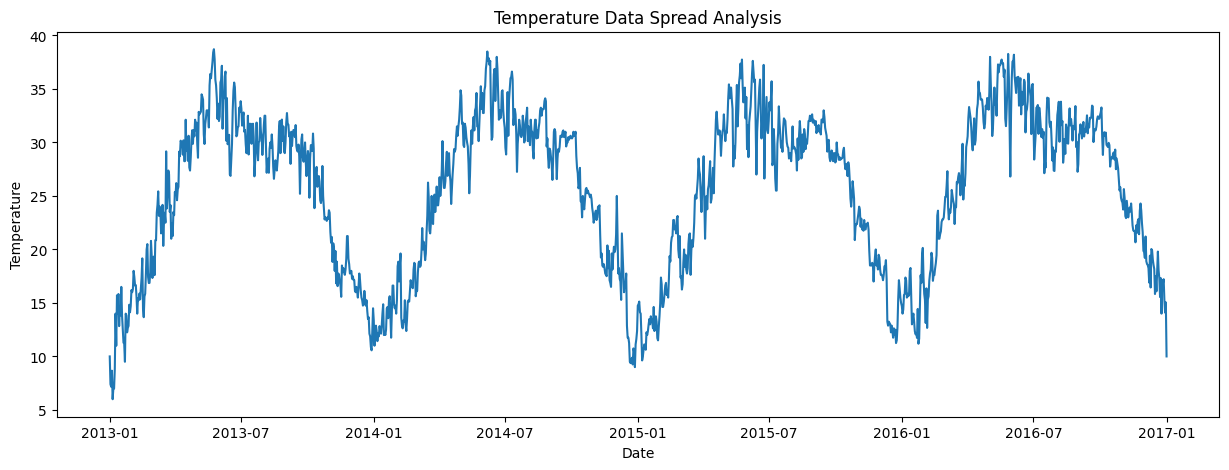

In [9]:
plt.figure(figsize=(15,5))
plt.plot(df['meantemp'], label='Mean Temperature')
plt.title('Temperature Data Spread Analysis')
plt.xlabel('Date')
plt.ylabel('Temperature')

Text(0, 0.5, 'Humidity')

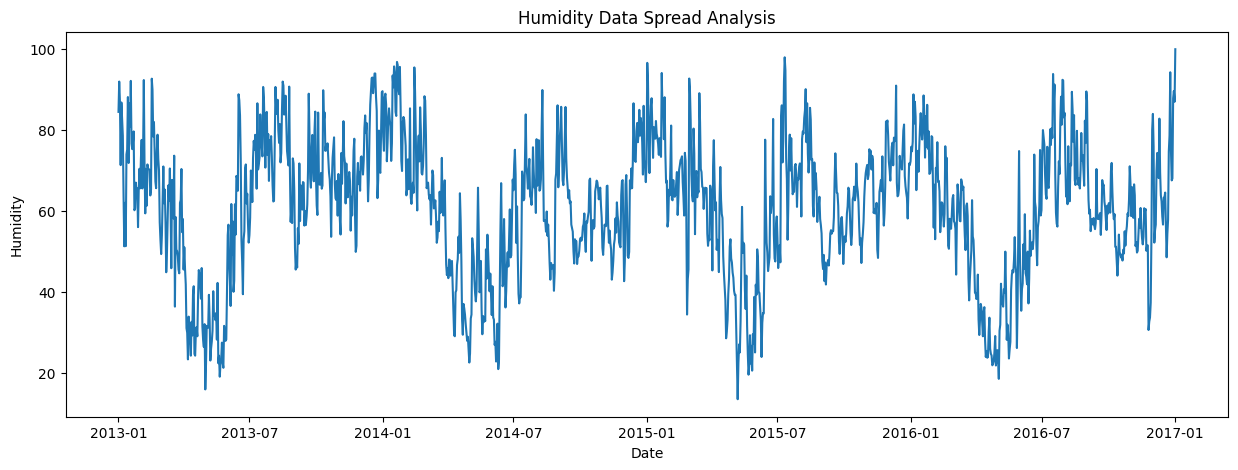

In [10]:
plt.figure(figsize=(15,5))
plt.plot(df['humidity'], label='Humidity')
plt.title('Humidity Data Spread Analysis')
plt.xlabel('Date')
plt.ylabel('Humidity')

Text(0, 0.5, 'Wind Speed')

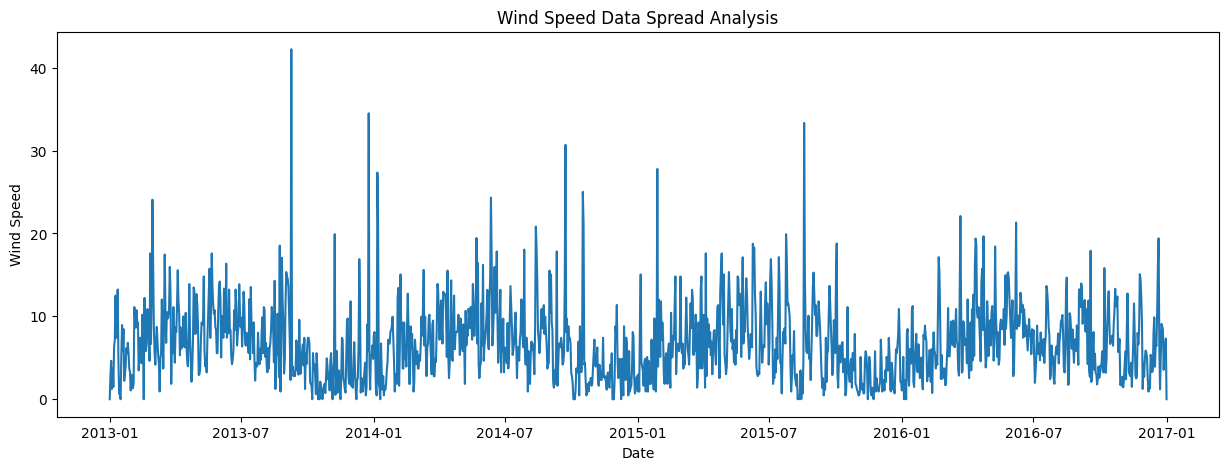

In [11]:
plt.figure(figsize=(15,5))
plt.plot(df['wind_speed'], label='wind_speed')
plt.title('Wind Speed Data Spread Analysis')
plt.xlabel('Date')
plt.ylabel('Wind Speed')

Text(0, 0.5, 'Mean Pressure')

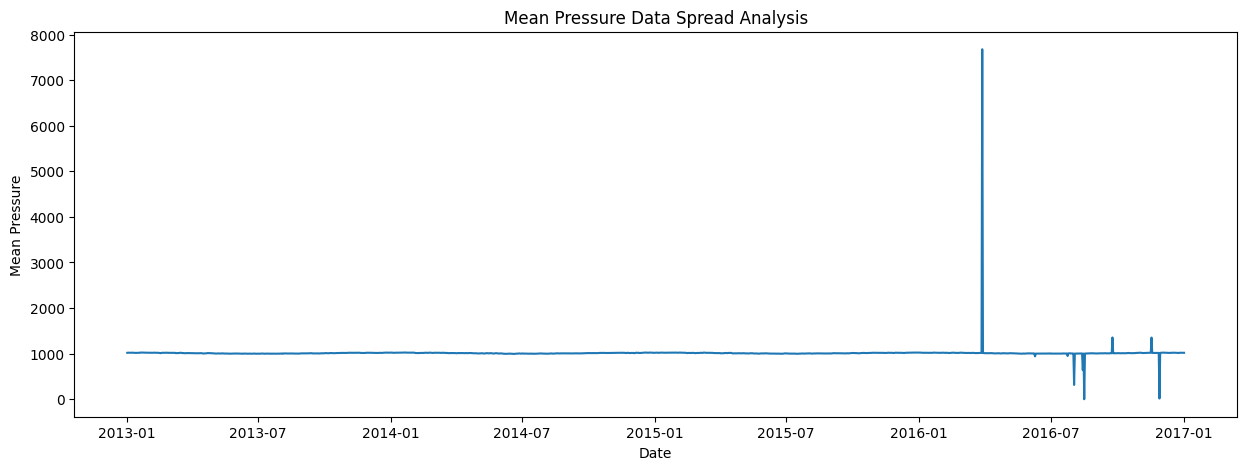

In [12]:
plt.figure(figsize=(15,5))
plt.plot(df['meanpressure'])
plt.title('Mean Pressure Data Spread Analysis')
plt.xlabel('Date')
plt.ylabel('Mean Pressure')

we can observe that meantemp, humidity, wind_speed follows time and pressure is alomst constant. Among this meantemp has a near perfect time series following, so we have 'meantemp' as target columns

In [13]:
#80:20 train_test_split

train_size = int(len(df)*0.8)

train_data = df.iloc[:train_size]
test_data=df.iloc[train_size:]

In [14]:
# Create separate scaler for target
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit separately
X_train = train_data.drop('meantemp', axis=1)
y_train = train_data[['meantemp']]

X_test = test_data.drop('meantemp', axis=1)
y_test = test_data[['meantemp']]

X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train)

# Transform test
X_test_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test)

create sequences, let us choose 30 days as window size

so the data looks like:

day1=[10,24,26,78,...80]

day2=[24,26,78,....,80,85]

day3=[26,78,79,....,80,85.90]

In [15]:
# 80:20 train_test_split
train_size = int(len(df) * 0.8)
train_data = df.iloc[:train_size]
test_data = df.iloc[train_size:]

In [16]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Split features and target
X_train = train_data.drop('meantemp', axis=1)
y_train = train_data[['meantemp']]
X_test = test_data.drop('meantemp', axis=1)
y_test = test_data[['meantemp']]

# Scale
X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train)
X_test_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test)

In [17]:
# Create sequences
def create_sequences(X, y, window_size):
    X_seq, y_seq = [], []
    for i in range(len(X) - window_size):
        X_seq.append(X[i : i + window_size])
        y_seq.append(y[i + window_size])
    return np.array(X_seq), np.array(y_seq)

WINDOW_SIZE = 30
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, WINDOW_SIZE)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, WINDOW_SIZE)

print(f'X_train_seq: {X_train_seq.shape}')
print(f'y_train_seq: {y_train_seq.shape}')
print(f'X_test_seq: {X_test_seq.shape}')
print(f'y_test_seq: {y_test_seq.shape}')

X_train_seq: (1139, 30, 3)
y_train_seq: (1139, 1)
X_test_seq: (263, 30, 3)
y_test_seq: (263, 1)


We create Validation Sequences to pass to the models during training

In [18]:
val_size = int(len(X_train_seq) * 0.2)
X_val_seq = X_train_seq[-val_size:]
y_val_seq = y_train_seq[-val_size:]
X_train_seq_final = X_train_seq[:-val_size]
y_train_seq_final = y_train_seq[:-val_size]

In [19]:
def create_rnn_model(window_size, n_features):
    model = Sequential([
        SimpleRNN(units=32, activation='tanh', return_sequences=True, input_shape=(window_size, n_features)),
        Dropout(0.2),
        SimpleRNN(units=64, activation='tanh', return_sequences=True),
        Dropout(0.2),
        SimpleRNN(units=128, activation='tanh'),
        Dropout(0.2),
        
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    print('RNN Model: ')
    model.summary()
    return model
    

In [20]:
def create_lstm_model(window_size, n_features):
    model = Sequential([
        LSTM(units=32, activation='tanh', return_sequences=True, input_shape=(window_size, n_features)),
        Dropout(0.2),
        LSTM(units=64, activation='tanh', return_sequences=True),
        Dropout(0.2),
        LSTM(units=128, activation='tanh'),
        Dropout(0.2),
        
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    print('LSTM Model: ')
    model.summary()
    return model

In [21]:
def create_gru_model(window_size, n_features):
    model = Sequential([
        GRU(units=32, activation='tanh', return_sequences=True, input_shape=(window_size, n_features)),
        Dropout(0.2),
        GRU(units=64, activation='tanh', return_sequences=True),
        Dropout(0.2),
        GRU(units=128, activation='tanh'),
        Dropout(0.2),
        
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')

    print('GRU Model: ')
    model.summary()
    return model

In [22]:
#RNN

rnn_model = create_rnn_model(WINDOW_SIZE, X_train_seq.shape[2])

start_time= time.time()
history_rnn = rnn_model.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_seq, y_val_seq),
    verbose=1
)
rnn_time= time.time()- start_time

RNN Model: 


2026-09-09 20:37:49.757420: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 30, 32)         │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 30, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,193 (125.75 KB)

 Trainable params: 32,193 (125.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.3663 - val_loss: 0.0208
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.2043 - val_loss: 0.0118
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1523 - val_loss: 0.0430
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.1262 - val_loss: 0.0897
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1039 - val_loss: 0.0178
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0924 - val_loss: 0.0105
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0736 - val_loss: 0.0080
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0671 - val_loss: 0.0221
Epoch 9/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0582 - val_loss: 0.0069
Epoch 10/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0516 - val_loss: 0.0081
Epoch 11/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0455 - val_loss: 0.0060
Epoch 12/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0

In [23]:
y_pred_rnn = rnn_model.predict(X_test_seq)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step


In [24]:
# Inverse transform 
y_test_actual = scaler_y.inverse_transform(y_test_seq)
y_pred_rnn_actual = scaler_y.inverse_transform(y_pred_rnn)

# Calculate metrics
rnn_mse = mean_squared_error(y_test_actual, y_pred_rnn_actual)
rnn_rmse = np.sqrt(rnn_mse)
rnn_mae = mean_absolute_error(y_test_actual, y_pred_rnn_actual)


# Print
print("RNN Performance Metrics:")
print(f"Execution Time: {rnn_time:.4f} seconds")
print(f"MSE: {rnn_mse:.4f}")
print(f"RMSE: {rnn_rmse:.4f}")
print(f"MAE: {rnn_mae:.4f}")


RNN Performance Metrics:
Execution Time: 46.5179 seconds
MSE: 23.2362
RMSE: 4.8204
MAE: 3.6522


In [25]:
LSTM

keras.src.layers.rnn.lstm.LSTM

In [26]:

lstm_model = create_lstm_model(WINDOW_SIZE, X_train_seq.shape[2])

start_time= time.time()
history_lstm = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_seq, y_val_seq),
    verbose=1
)
lstm_time= time.time()- start_time

LSTM Model: 


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 32)         │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,385 (501.50 KB)

 Trainable params: 128,385 (501.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - loss: 0.0987 - val_loss: 0.0199
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0153 - val_loss: 0.0107
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0097 - val_loss: 0.0069
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0095 - val_loss: 0.0063
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0088 - val_loss: 0.0043
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0090 - val_loss: 0.0058
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0089 - val_loss: 0.0049
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0084 - val_loss: 0.0093
Epoch 9/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0088 - val_loss: 0.0062
Epoch 10/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0087 - val_loss: 0.0105
Epoch 11/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0086 - val_loss: 0.0049
Epoch 12/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0

In [27]:
y_pred_lstm = lstm_model.predict(X_test_seq)

# Inverse transform 
y_test_actual = scaler_y.inverse_transform(y_test_seq)
y_pred_lstm_actual = scaler_y.inverse_transform(y_pred_lstm)

# Calculate metrics
lstm_mse = mean_squared_error(y_test_actual, y_pred_lstm_actual)
lstm_rmse = np.sqrt(lstm_mse)
lstm_mae = mean_absolute_error(y_test_actual, y_pred_lstm_actual)

# Print
print("LSTM Performance Metrics:")
print(f"Execution Time: {lstm_time:.4f} seconds")
print(f"MSE: {lstm_mse:.4f}")
print(f"RMSE: {lstm_rmse:.4f}")
print(f"MAE: {lstm_mae:.4f}")


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step
LSTM Performance Metrics:
Execution Time: 105.0928 seconds
MSE: 17.2911
RMSE: 4.1583
MAE: 3.2726


GRU

In [28]:
gru_model = create_gru_model(WINDOW_SIZE, X_train_seq.shape[2])

start_time= time.time()
history_gru = gru_model.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_seq, y_val_seq),
    verbose=1
)
gru_time= time.time()- start_time

GRU Model: 


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 32)         │         3,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 30, 64)         │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 128)            │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,993 (378.88 KB)

 Trainable params: 96,993 (378.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step - loss: 0.0734 - val_loss: 0.0135
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0169 - val_loss: 0.0125
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0133 - val_loss: 0.0091
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0117 - val_loss: 0.0074
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0104 - val_loss: 0.0060
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0096 - val_loss: 0.0090
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0085 - val_loss: 0.0049
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0090 - val_loss: 0.0055
Epoch 9/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0079 - val_loss: 0.0047
Epoch 10/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0076 - val_loss: 0.0057
Epoch 11/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0079 - val_loss: 0.0049
Epoch 12/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0

In [29]:
y_pred_gru = gru_model.predict(X_test_seq)

# Inverse transform 
y_test_actual = scaler_y.inverse_transform(y_test_seq)
y_pred_gru_actual = scaler_y.inverse_transform(y_pred_gru)

# Calculate metrics
gru_mse = mean_squared_error(y_test_actual, y_pred_gru_actual)
gru_rmse = np.sqrt(gru_mse)
gru_mae = mean_absolute_error(y_test_actual, y_pred_gru_actual)

# Print
print("GRU Performance Metrics:")
print(f"Execution Time: {gru_time:.4f} seconds")
print(f"MSE: {gru_mse:.4f}")
print(f"RMSE: {gru_rmse:.4f}")
print(f"MAE: {gru_mae:.4f}")


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step
GRU Performance Metrics:
Execution Time: 106.8543 seconds
MSE: 21.7120
RMSE: 4.6596
MAE: 3.2129


Analysis

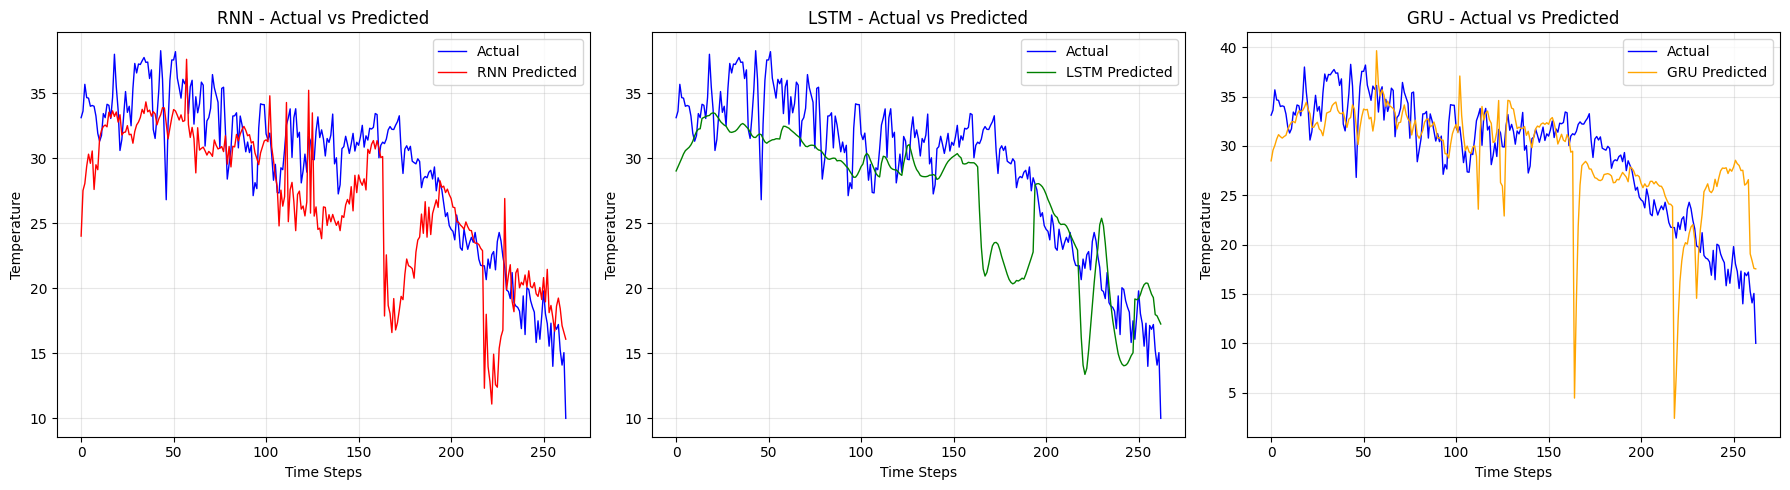

In [30]:
# Plot
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(y_test_actual, label='Actual', color='blue', linewidth=1)
plt.plot(y_pred_rnn_actual, label='RNN Predicted', color='red', linewidth=1)
plt.title('RNN - Actual vs Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(y_test_actual, label='Actual', color='blue', linewidth=1)
plt.plot(y_pred_lstm_actual, label='LSTM Predicted', color='green', linewidth=1)
plt.title('LSTM - Actual vs Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(y_test_actual, label='Actual', color='blue', linewidth=1)
plt.plot(y_pred_gru_actual, label='GRU Predicted', color='orange', linewidth=1)
plt.title('GRU - Actual vs Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

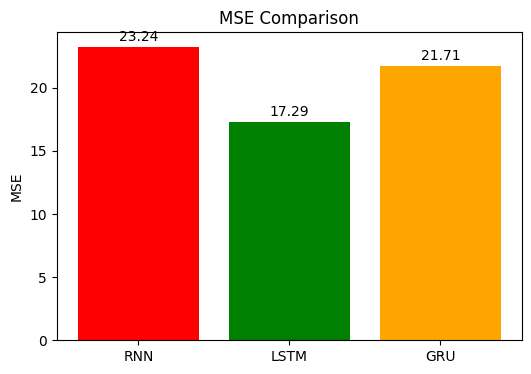

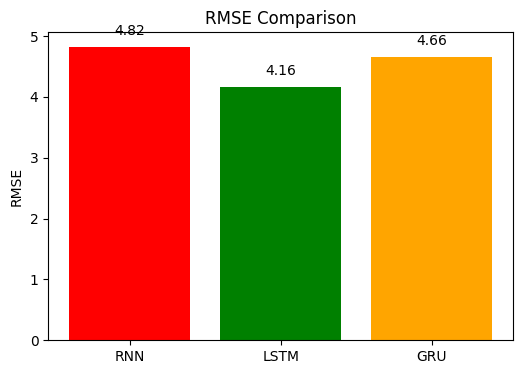

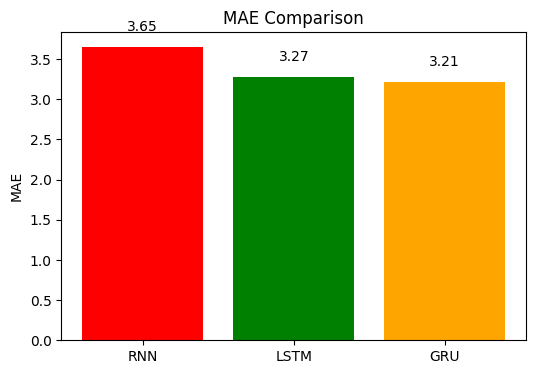

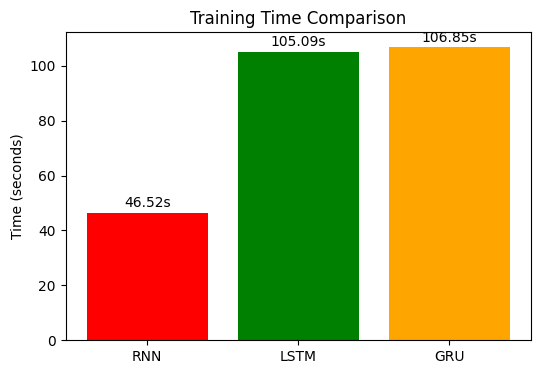

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics data
models = ['RNN', 'LSTM', 'GRU']
mse = [23.2362, 17.2911, 21.7120]
rmse = [4.8204, 4.1583, 4.6596]
mae = [3.6522, 3.2726, 3.2129]
training_time = [46.5179, 105.0928, 106.8543]

# MSE Bar Graph
plt.figure(figsize=(6, 4))
plt.bar(models, mse, color=['red', 'green', 'orange'])
plt.title('MSE Comparison')
plt.ylabel('MSE')
for i, v in enumerate(mse):
    plt.text(i, v + 0.5, f'{v:.2f}', ha='center')
plt.show()

# RMSE Bar Graph
plt.figure(figsize=(6, 4))
plt.bar(models, rmse, color=['red', 'green', 'orange'])
plt.title('RMSE Comparison')
plt.ylabel('RMSE')
for i, v in enumerate(rmse):
    plt.text(i, v + 0.2, f'{v:.2f}', ha='center')
plt.show()

# MAE Bar Graph
plt.figure(figsize=(6, 4))
plt.bar(models, mae, color=['red', 'green', 'orange'])
plt.title('MAE Comparison')
plt.ylabel('MAE')
for i, v in enumerate(mae):
    plt.text(i, v + 0.2, f'{v:.2f}', ha='center')
plt.show()

# Training Time Comparison
plt.figure(figsize=(6, 4))
plt.bar(models, training_time, color=['red', 'green', 'orange'])
plt.title('Training Time Comparison')
plt.ylabel('Time (seconds)')
for i, v in enumerate(training_time):
    plt.text(i, v + 2, f'{v:.2f}s', ha='center')
plt.show()

LSTM has the overall low MAE, MSE, RMSE

Its execution time is also less but similar to LSTM